In [1]:
import joblib
import numpy as np
import json
from copy import deepcopy
import jax
import pennylane as qml
import csv
import json
import os
import pandas as pd
import shap
import jax.numpy as jnp
import tensorflow as tf
import shap
from libs import circuits, dataloading, qnn_models
from libs.helpers import mix_with_white
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from cmcrameri import cm
from libs.helpers import mix_with_white
from matplotlib.ticker import LogLocator, LogFormatter, FuncFormatter
from joblib import Parallel, delayed
import re
plt.style.use('./libs/notebookstyle_aps.mplstyle')

%load_ext autoreload
%autoreload 2

2026-06-26 10:49:02.158952: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-26 10:49:02.158999: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-26 10:49:02.159859: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-26 10:49:03.471954: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## Data loading

In [2]:
jnp_train_inputs, jnp_val_inputs, jnp_train_outputs, jnp_val_outputs = dataloading.load_data(0, n_samples = 'all')

In [3]:
# choose large values for accurate estimate with Kernel SHAP
background = np.array(jnp_train_inputs[:200])  
sample = np.array(jnp_val_inputs[:1000])

In [4]:
feature_names = ['$p$','$\\theta$','$z$/ABL','$u$','$v$','$w$']

## Shapley values of the classical NN

In [5]:
def shap_analysis_cl(model_name, j, save = True):
    
    model = tf.keras.models.load_model("./cl_models/%s_%i"%(model_name,j))
    
    explainer = shap.KernelExplainer(model, background)
    
    shap_values = explainer.shap_values(sample, nsamples=len(sample))[:,:,0]

    file_path = f'./cl_results/{model.name}_{j}_shap.npz'
    if save:
        np.savez(file_path,     shap_values=shap_values)
    
    shap.summary_plot(shap_values, sample, feature_names=feature_names)


In [6]:
model_list_all = !ls './cl_models/'
model_list = [s for s in model_list_all if ((s[-2:] == '_1') and ('_' in s[:-2]))]
models = []
n_params = []
for model1 in model_list:
    model = tf.keras.models.load_model('./cl_models/' + model1)
    models += [model]
    n_params += [[model.name, model.count_params()]]
model_list_unique = [s[:-2] for s in model_list]

In [7]:
for j in range(1,11):
    for model_name in model_list_unique:
        file_path = f"./cl_results/{model_name}_{j}_shap.npz"

        if not os.path.exists(file_path):
            shap_analysis_cl(model_name, j)
        else:        
            print(model_name, j, 'exists')

sequential_100 1 exists
sequential_101 1 exists
sequential_102 1 exists
sequential_103 1 exists
sequential_104 1 exists
sequential_105 1 exists
sequential_106 1 exists
sequential_107 1 exists
sequential_108 1 exists
sequential_109 1 exists
sequential_110 1 exists
sequential_111 1 exists
sequential_112 1 exists
sequential_113 1 exists
sequential_114 1 exists
sequential_115 1 exists
sequential_116 1 exists
sequential_117 1 exists
sequential_118 1 exists
sequential_119 1 exists
sequential_120 1 exists
sequential_121 1 exists
sequential_122 1 exists
sequential_123 1 exists
sequential_124 1 exists
sequential_125 1 exists
sequential_126 1 exists
sequential_127 1 exists
sequential_128 1 exists
sequential_129 1 exists
sequential_130 1 exists
sequential_13 1 exists
sequential_131 1 exists
sequential_132 1 exists
sequential_133 1 exists
sequential_134 1 exists
sequential_135 1 exists
sequential_137 1 exists
sequential_15 1 exists
sequential_2 1 exists
sequential_240 1 exists
sequential_242 1 exi

## Shapley values of the QNN

In [8]:
key = jax.random.PRNGKey(12345)
keys = jax.random.split(key, 10)

In [9]:
save_dir = './QNN_results/'

def shap_analysis(n_enc, n_dec, n_qubits, local_observable, key, enc_angles, save = True):
    
    mycircuit = circuits.PQCircuit(n_enc, n_dec, n_qubits, var_angles = 'XYZ', encoding_angles=enc_angles, choose_freq = True)
        
    dev = qml.device("default.qubit", wires=n_qubits)
    
    model_qnn, no_params, model_name = qnn_models.make_model(dev, mycircuit, local_observable)

    file_path = f'{save_dir}{model_name}_shap{key}.npz'

    if not os.path.exists(file_path):

        pars = np.load(f'{save_dir}{model_name}_optparams{key}.npz')['opt_params']
        
        circuit = mycircuit
        if local_observable:
                observable_indices = list(range(circuit.n_wires))
                obs_return = lambda: [qml.expval(qml.PauliZ(i)) for i in observable_indices]
        else:
            full_obs = reduce(lambda x, y: x @ y, [qml.PauliZ(i) for i in range(circuit.n_wires)])
            obs_return = lambda: [qml.expval(full_obs)]
                
        @qml.qnode(dev, interface="jax")
        def qnn_pqc(inputs, angles):
            circuit(inputs, angles,  dev.wires)
            return obs_return()
    
        def qnn_single(inputs, angles):
            inputs = inputs[None, :]
            out = qnn_pqc(inputs, angles)
            return out[0]
        
        qnn_batch = jax.vmap(lambda x: qnn_single(x, pars))

        #### need to redefine model for shapes of arrays to work out
        def qnn_shap_model(X):
            X = jnp.array(X)
        
            if X.ndim == 1:
                X = X[None, :]
        
            outputs = qnn_batch(X)
            return np.array(outputs)
        
        # For first qubit only
        def qnn_shap_model_single(X):
            return qnn_shap_model(X)[:, 0]
        
        explainer = shap.KernelExplainer(qnn_shap_model_single, background)
        
        shap_values = explainer.shap_values(sample, nsamples=len(sample))
        if save:
            np.savez(f'{save_dir}{model_name}_shap{key}.npz', shap_values = shap_values)
        
        shap.summary_plot(shap_values, sample, feature_names=feature_names)

In [10]:
calc_qnn_shap = False
def run_one_shap(n_enc, n_dec, n_qubits, enc_angles, local_observable, key_j):
    try:
        shap_analysis(
            n_enc,
            n_dec,
            n_qubits,
            local_observable,
            key_j,
            enc_angles,
        )
        return True
    except Exception as e:
        print(
            f"nonexistent or failed: nq={n_qubits}, enc={n_enc}, dec={n_dec}, "
            f"local={local_observable}, key={key_j}"
        )
        return False

if calc_qnn_shap:
    tasks = [
        (n_enc, n_dec, n_qubits, enc_angles, local_observable, key_j)
        for [n_qubits, enc_angles] in [[2,"XYZ"],[3,"XY"],[4,"XYZ"],[6,"X"], [6,"XY"], [8, 'XY']]
        for n_enc in range(1, 10)
        for n_dec in range(1, 10)
        for local_observable in [0, 1]
        for key_j in keys
    ]
    
    n_jobs = int(os.environ.get("SLURM_CPUS_PER_TASK", os.cpu_count() // 2))
    
    results = Parallel(
        n_jobs=n_jobs,
        backend="loky",
        verbose=10,
    )(
        delayed(run_one_shap)(*task) for task in tasks
    )
    
    
    n_fail = results.count(False)
    print("Done.")


## Figure

In [11]:
model_list_all = !ls './cl_models/'
model_list_2 = [s for s in model_list_all if (s[-2:] == '_1')]
models = []
n_params = []
n_layers = []
model_list_unique = []
for model1 in model_list_2:
    model = tf.keras.models.load_model('./cl_models/' + model1)
    models += [model]
    n_params += [[model.name, model.count_params()]]
    n_layers += [[model.name,len(model.layers)]]
    model_list_unique += [model.name]
    print(len(model.layers))

2
5
2
2
5
6
5
2
4
4
4
4
2
2
3
2
3
5
2
3
3
2
5
2
3
2
3
4
3
2
4
2
4
5
2
2
3
3
3
2
4
2
5
3
2
2
2


In [12]:
save_dir_cl = './cl_results/'
feature_names = ['$p$','$\\theta$','$z$/ABL','$u$','$v$','$w$']

In [13]:
rows = []

for model_name in model_list_unique:
        per_j_feature_means = []
    
        for j in range(1, 11):
            path = f'{save_dir_cl}{model_name}_{j}_shap.npz'
            shap = np.load(path)['shap_values']
    
            feature_mean = np.mean(np.abs(shap), axis=0)  # (n_features,)
            per_j_feature_means.append(feature_mean)
    
        per_j_feature_means = np.array(per_j_feature_means)  # (10, n_features)
    
        mean_over_j = np.mean(per_j_feature_means, axis=0)
        std_over_j = np.std(per_j_feature_means, axis=0)
    
        for i, (mu, sigma) in enumerate(zip(mean_over_j, std_over_j)):
            rows.append({
                "model": model_name,
                "n_params":dict(n_params)[model_name],
                "n_layers":dict(n_layers)[model_name],
                "feature": feature_names[i],
                "mean_shap": mu,
                "std_shap": sigma
            })

df_shap_cl = pd.DataFrame(rows)


In [14]:
rows = []

for model_name in model_list_unique:
        for j in range(1, 11):  # runs
            path = f"{save_dir_cl}{model_name}_{j}_shap.npz"
            shap = np.load(path)["shap_values"]  # (n_samples, n_features)
    
            feature_shap = np.mean(np.abs(shap), axis=0)  # (n_features,)
    
            for i, val in enumerate(feature_shap):
                rows.append({
                    "model_name": model_name,
                    "key": j,
                    "n_params": dict(n_params)[model_name],
                    "n_layers": dict(n_layers)[model_name],
                    "feature": feature_names[i],
                    "single_shap": val,
                })

df_shap_cl_single = pd.DataFrame(rows)


In [15]:
rows = []
save_dir_qu = './QNN_results/'
var_angles = 'XYZ'
for [n_qubits, encoding_angles] in [[2,"XYZ"],[3,"XY"],[4,"XYZ"],[6,"X"], [6,"XY"],[8,"XY"]]:
    for n_enc in range(1,10):
        for n_dec in range(0,10):
            for local_observable in [0,1]:
                try:
                    model_name = model_name = str(n_qubits) + 'qubits_' + 'circuit_'+encoding_angles+'_'+var_angles+'_freq' + str(n_enc)+'enc_' + str(n_dec)+'dec_' +('' if local_observable else 'non') + 'local'
                    per_j_feature_means = []
                    
                    for key_j in keys:
                            shap = np.load(f'{save_dir_qu}{model_name}_shap{key_j}.npz')['shap_values']
                                
                            feature_mean = np.mean(np.abs(shap), axis=0)  # (n_features,)
                            per_j_feature_means.append(feature_mean)
                        
                    per_j_feature_means = np.array(per_j_feature_means)  # (10, n_features)
                    if per_j_feature_means.ndim == 1:
                        per_j_feature_means = per_j_feature_means[np.newaxis, :]
                
                    mean_over_j = np.mean(per_j_feature_means, axis=0)
                    std_over_j = np.std(per_j_feature_means, axis=0)
                
                    for i, (mu, sigma) in enumerate(zip(mean_over_j, std_over_j)):
                        rows.append({
                            "model": model_name,
                            "feature": feature_names[i],
                            "mean_shap": mu,
                            "std_shap": sigma
                        })
                except:
                    print( n_qubits, encoding_angles, n_enc, n_dec, local_observable, 'nonexistent combo or error')
                    
df_shap_qu = pd.DataFrame(rows)

2 XYZ 1 0 0 nonexistent combo or error
2 XYZ 1 0 1 nonexistent combo or error
2 XYZ 1 7 0 nonexistent combo or error
2 XYZ 1 7 1 nonexistent combo or error
2 XYZ 1 8 0 nonexistent combo or error
2 XYZ 1 8 1 nonexistent combo or error
2 XYZ 1 9 0 nonexistent combo or error
2 XYZ 1 9 1 nonexistent combo or error
2 XYZ 2 0 0 nonexistent combo or error
2 XYZ 2 0 1 nonexistent combo or error
2 XYZ 2 7 0 nonexistent combo or error
2 XYZ 2 7 1 nonexistent combo or error
2 XYZ 2 8 0 nonexistent combo or error
2 XYZ 2 8 1 nonexistent combo or error
2 XYZ 2 9 0 nonexistent combo or error
2 XYZ 2 9 1 nonexistent combo or error
2 XYZ 3 0 0 nonexistent combo or error
2 XYZ 3 0 1 nonexistent combo or error
2 XYZ 3 7 0 nonexistent combo or error
2 XYZ 3 7 1 nonexistent combo or error
2 XYZ 3 8 0 nonexistent combo or error
2 XYZ 3 8 1 nonexistent combo or error
2 XYZ 3 9 0 nonexistent combo or error
2 XYZ 3 9 1 nonexistent combo or error
2 XYZ 4 0 0 nonexistent combo or error
2 XYZ 4 0 1 nonexistent c

In [16]:
def parse_config(s):
    match = re.match(r"(\d+)qubits_circuit_([a-zA-Z]+)_([a-zA-Z]+)_freq(\d+)enc_(\d+)dec_([a-zA-Z]+)", s)
    if match:
        qubits, enc_angles, angles, n_enc, n_dec,  entanglement = match.groups()
        return int(qubits), int(n_enc), int(n_dec), entanglement, angles, enc_angles
    return None, None, None, None

df_shap_qu[['n_qubits', 'n_enc', 'n_dec', 'entanglement','angles','enc_angles']] = df_shap_qu['model'].apply(
    lambda x: pd.Series(parse_config(x))
)

def getpars(df):
    return df.n_qubits*(df.n_enc + df.n_dec)*df.angles.apply(lambda s: len(s)) + df.n_qubits*df.n_enc*df.enc_angles.apply(lambda s: len(s))

df_shap_qu['nonlocal'] = (df_shap_qu.entanglement == 'nonlocal')*1.
df_shap_qu['n_params'] = getpars(df_shap_qu)

In [17]:
rows = []

save_dir_qu = "./QNN_results/"
var_angles = "XYZ"

for [n_qubits, encoding_angles] in [[2,"XYZ"],[3,"XY"],[4,"XYZ"],[6,"X"], [6,"XY"],[8,"XY"]]:

    for n_enc in range(1, 10):
        for n_dec in range(0, 10):
            for local_observable in [0, 1]:
                model_name = (
                    f"{n_qubits}qubits_circuit_"
                    f"{encoding_angles}_{var_angles}_"
                    f"freq{n_enc}enc_{n_dec}dec_"
                    f"{'' if local_observable else 'non'}local"
                )

                for key in keys: 
                    try:
                        shap = np.load(
                            f"{save_dir_qu}{model_name}_shap{key}.npz"
                        )["shap_values"] 

                        feature_shap = np.mean(
                            np.abs(shap), axis=0
                        )  # (n_features,)

                        for i, val in enumerate(feature_shap):
                            rows.append({
                                "model_name": model_name,
                                "key": key,
                                "n_qubits": n_qubits,
                                "n_enc": n_enc,
                                "n_dec": n_dec,
                                "local_observable": local_observable,
                                "feature": feature_names[i],
                                "single_shap": val,
                            })

                    except FileNotFoundError:
                        continue
                    except Exception as e:
                        print(model_name, key, e)

df_shap_qu_single = pd.DataFrame(rows)
df_shap_qu_single = df_shap_qu_single[np.isin(df_shap_qu_single.model_name, df_shap_qu.model.values)]

252 max params of the QNN


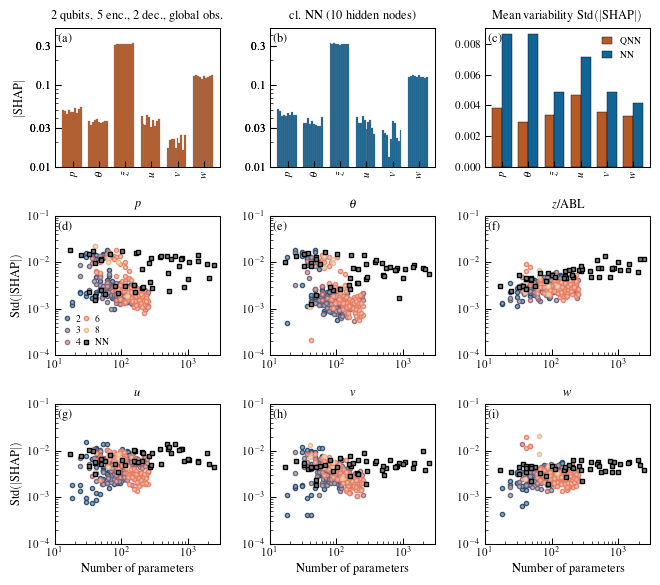

In [18]:
COLOR_QU = cm.vik(0.8)
COLOR_CL = cm.vik(0.2)

fig = plt.figure(figsize=(6.77, 6))

gs = gridspec.GridSpec(
    3, 3,
    hspace=0.35,
    wspace=0.30
)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[0, 2])

# example models
QU_MODEL = "2qubits_circuit_XYZ_XYZ_freq5enc_2dec_nonlocal"
CL_MODEL = "sequential_133"

df_qu_ex = df_shap_qu_single.query("model_name == @QU_MODEL").copy()
df_cl_ex = df_shap_cl_single.query("model_name == @CL_MODEL").copy()

def canon_key(k):
    return tuple(np.asarray(k).ravel())

df_qu_ex["key_canon"] = df_qu_ex["key"].apply(canon_key)
df_cl_ex["key_canon"] = df_cl_ex["key"].apply(canon_key)

qu_keys = df_qu_ex["key_canon"].unique()
cl_keys = df_cl_ex["key_canon"].unique()

features = df_qu_ex["feature"].unique()
x = np.arange(len(features))

# compute variability
std_qu = (
    df_shap_qu_single
    .groupby(["model_name", "feature"])["single_shap"]
    .std()
    .groupby("feature")
    .mean()
    .reindex(features)
)

std_cl = (
    df_shap_cl_single[df_shap_cl_single.n_params <= df_shap_qu.n_params.max()]
    .groupby(["model_name", "feature"])["single_shap"]
    .std()
    .groupby("feature")
    .mean()
    .reindex(features)
)

print(df_shap_qu.n_params.max(), 'max params of the QNN')


width = 0.75 / len(qu_keys)

for i, key in enumerate(qu_keys):
    vals = (
        df_qu_ex[df_qu_ex.key_canon == key]
        .set_index("feature")
        .reindex(features)["single_shap"]
    )
    ax_a.bar(
        x - 0.375 + i * width,
        vals,
        width=width,
        color=COLOR_QU,
        edgecolor="grey",
        linewidth = 0.2
    )

ax_a.set_title("2 qubits, 5 enc., 2 dec., global obs.", fontsize=9)
ax_a.set_ylabel(r"$|\mathrm{SHAP}|$", fontsize=9)


for i, key in enumerate(cl_keys):
    vals = (
        df_cl_ex[df_cl_ex.key_canon == key]
        .set_index("feature")
        .reindex(features)["single_shap"]
    )
    ax_b.bar(
        x - 0.375 + i * width,
        vals,
        width=width,
        color=COLOR_CL,
        edgecolor="grey",
        linewidth = 0.2
    )

ax_b.set_title("cl. NN (10 hidden nodes)", fontsize=9)


w = 0.38
ax_c.bar(x - w/2, std_qu, w, color=COLOR_QU, edgecolor="black", linewidth=0.3, label="QNN")
ax_c.bar(x + w/2, std_cl, w, color=COLOR_CL, edgecolor="black", linewidth=0.3, label="NN")


ax_c.set_ylabel("Std |SHAP| over repetitions")
ax_c.set_title(r"Mean variability $\mathrm{Std}(|\mathrm{SHAP}|)$", fontsize=9)
ax_c.legend(loc="upper right",
    frameon=False,
    fontsize=7,
    #ncol = 1,
    labelcolor=None, borderpad=0.5,
    labelspacing=0.5, handlelength=1,
    borderaxespad=0.5, #columnspacing=0.5, 
    #bbox_to_anchor=(.05, 0.03),
           )

features1 = np.array(['$p$', '$\\theta$', '$\\tilde{z}$', '$u$', '$v$', '$w$'])


for ax in [ax_a, ax_b, ax_c]:
    ax.set_xticks(x)
    ax.set_xticklabels(features1, rotation=90, fontsize=8)
    ax.set_xlabel("") 
    ax.tick_params(labelsize=8)
    
for ax in [ax_a, ax_b]:
    ax.set_ylim(0.01,0.5)

ax_b.set_ylabel("")
ax_c.set_ylabel("")



for ax in [ax_a, ax_b]:
    ax.set_yscale('log')
    ax.yaxis.set_major_locator(
    LogLocator(base=10, subs=(0.03,0.1,0.3,1.0, 3.0)))

    ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x:g}"))



qubit_groups = sorted(df_shap_qu['n_qubits'].unique())
colors_qu = cm.lipari(np.linspace(0.15, 0.85, len(qubit_groups)))

for i, feat in enumerate(features):
    ax = fig.add_subplot(gs[1 + i // 3, i % 3])

    for c, nq in zip(colors_qu, qubit_groups):
        sub_qu = df_shap_qu[
            (df_shap_qu['feature'] == feat) &
            (df_shap_qu['n_qubits'] == nq)
        ]
        if len(sub_qu) == 0:
            continue

        ax.plot(
            sub_qu['n_params'],
            sub_qu['std_shap'],
            'o',
            color=c,
            markersize=3,
            markerfacecolor = mix_with_white(c,0.5),
            alpha=0.9,
            label=f'{nq}' if i == 0 else None,
        )

    sub_nn = df_shap_cl[(df_shap_cl['feature'] == feat)]
    ax.plot(
        sub_nn['n_params'],
        sub_nn['std_shap'],
        's',
        color='k',
        markersize=3,
        markerfacecolor = mix_with_white('k',0.5),
        label='NN' if i == 0 else None,
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(10, 3e3)
    ax.set_ylim(1e-4,.1)
    ax.set_title(feat, fontsize=9)


    if np.isin(i,[3,4,5]):
        ax.set_xlabel("Number of parameters", fontsize=9)
    else:
        ax.set_xlabel("")

    if i % 3 == 0:
        ax.set_ylabel(r"$\mathrm{Std}(|\mathrm{SHAP}|)$", fontsize=9)
    else:
        ax.set_ylabel("")

    ax.tick_params(labelsize=8)


handles, labels = fig.axes[3].get_legend_handles_labels()
fig.axes[3].legend(
    handles,
    labels,
    loc="lower left",
    frameon=False,
    fontsize=7,
    ncol = 2,
    labelcolor=None, borderpad=0.2,
    labelspacing=0.3, handlelength=0.15, handleheight=None, handletextpad=None,
    borderaxespad=0.2, columnspacing=0.5, 
    bbox_to_anchor=(.05, 0.03),
)


plt.subplots_adjust(
    left=0.10,
    right=0.98,
    bottom=0.07,
    top=0.93,
)

for ax, lab in zip(fig.axes, ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)", "(i)"]):
    ax.text(0.02, 0.96, lab, transform=ax.transAxes,
            va="top", ha="left", fontsize=9)

fig.savefig("./figures/shap_9panel.jpg")


<Axes: xlabel='feature'>

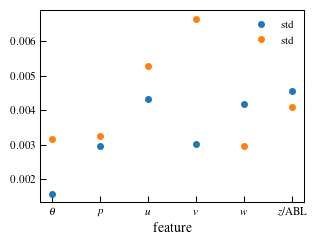

In [19]:
df_qu_ex.groupby('feature').single_shap.aggregate(['std']).plot(ax = plt.gca(), linestyle = '', marker = 'o')
df_cl_ex.groupby('feature').single_shap.aggregate(['std']).plot(ax = plt.gca(), linestyle = '', marker = 'o')

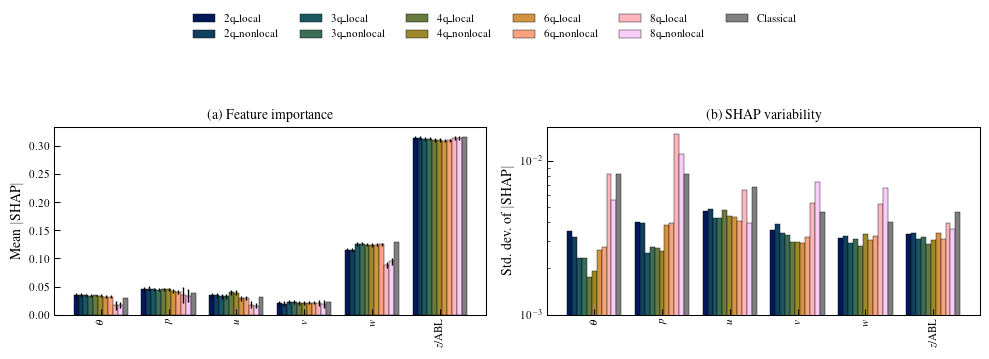

In [20]:
# -------------------------------
# ALL-IN-ONE CELL
# -------------------------------
import numpy as np
import matplotlib.pyplot as plt
from cmcrameri import cm

# -------------------------------
# Filter data
# -------------------------------
df_shap_f    = df_shap_cl.query("0 <= n_params <= 252").copy()
df_shap_qu_f = df_shap_qu.query("0 <= n_params <= 252").copy()

# -------------------------------
# Create condition label (qubits + observable)
# -------------------------------
df_shap_qu_f["condition"] = (
    df_shap_qu_f["n_qubits"].astype(str) + "q_" +
    df_shap_qu_f["entanglement"].astype(str)
)

# -------------------------------
# Aggregate quantum data
# -------------------------------
mean_qu = (
    df_shap_qu_f.groupby(["feature", "condition"])["mean_shap"]
    .mean()
    .unstack()
)

std_qu = (
    df_shap_qu_f.groupby(["feature", "condition"])["std_shap"]
    .mean()
    .unstack()
)

# -------------------------------
# Aggregate classical baseline
# -------------------------------
mean_cl = df_shap_f.groupby("feature")["mean_shap"].mean()
std_cl  = df_shap_f.groupby("feature")["std_shap"].mean()

# Ensure same feature order
features = mean_qu.index
mean_cl = mean_cl.reindex(features)
std_cl  = std_cl.reindex(features)

conditions = mean_qu.columns

# -------------------------------
# Plot setup
# -------------------------------
x = np.arange(len(features))
n_cond = len(conditions)
width = 0.8 / (n_cond + 1)

colors = cm.batlow(np.linspace(0, 1, n_cond))

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharex=True)

# -------------------------------
# (a) Mean |SHAP|
# -------------------------------
for i, cond in enumerate(conditions):
    axes[0].bar(
        x + (i - n_cond/2)*width,
        mean_qu[cond],
        width,
        yerr=std_qu[cond],
        color=colors[i],
        label=cond,
        edgecolor="black",
        linewidth=0.3,
    )

# Classical baseline
axes[0].bar(
    x + (n_cond/2)*width,
    mean_cl,
    width,
    color="gray",
    label="Classical",
    edgecolor="black",
    linewidth=0.3,
)

axes[0].set_ylabel(r"Mean $|\mathrm{SHAP}|$")
axes[0].set_title("(a) Feature importance")

# -------------------------------
# (b) Std deviation
# -------------------------------
for i, cond in enumerate(conditions):
    axes[1].bar(
        x + (i - n_cond/2)*width,
        std_qu[cond],
        width,
        color=colors[i],
        edgecolor="black",
        linewidth=0.3,
    )

axes[1].bar(
    x + (n_cond/2)*width,
    std_cl,
    width,
    color="gray",
    edgecolor="black",
    linewidth=0.3,
)

axes[1].set_yscale("log")
axes[1].set_ylabel(r"Std. dev. of $|\mathrm{SHAP}|$")
axes[1].set_title("(b) SHAP variability")
axes[1].set_ylim(1e-3,)
# -------------------------------
# Formatting
# -------------------------------
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(features, rotation=90)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=min(6, len(labels)),
    frameon=False,
    bbox_to_anchor=(0.5, 1.2),
)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()